# Raport: Wykrywanie naczyń dna siatkówki oka

https://github.com/viatrix17/Wykrywanie-naczyn-dna-siatkowki-oka

#### Skład grupy

Julia Kardasz 160204
Szymon Wójtowicz 160109

### Biblioteki

In [26]:
import os
import random
import matplotlib.pyplot as plt
from scipy import misc
import numpy as np
from PIL import Image
import skimage
from skimage import exposure, filters, morphology, color
from skimage.util import view_as_windows
from skimage.measure import moments, moments_central, moments_hu, moments_normalized
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

In [27]:
class StopNotebook(Exception):
    def __init__(self, msg="Brak dodatkowych informacji."):
        self.msg = msg
        
    def _render_traceback_(self):
        return [f"--- NOTATNIK ZATRZYMANY ---", f"Powód: {self.msg}"]

# Implementacja

## Wczytywanie plików 

In [28]:
def open_image_file(path):
    print(f"Opening file {path}")
    if os.path.exists(path):
        img = Image.open(path).convert('RGB')
        root, extension = os.path.splitext(path)
    else:
        raise StopNotebook(msg="Nie można znaleźć pliku.")

    img = np.array(img)
    return img

## Wstępne przetwarzanie obrazu

In [29]:
def extract_channels(img):
    r = img.copy()
    r[:,:,1] = r[:,:,2] = 0

    g = img.copy()
    g[:,:,0] = g[:,:,2] = 0

    b = img.copy()
    b[:,:,0] = b[:,:,1] = 0

    return r,g,b

def preprocess_image(img):
    print("Preprocessing the image...")
    # normalization
    img_eq = exposure.equalize_adapthist(img)
    # noise reduction
    img_clean = filters.median(img_eq)
    return img_clean

## Właściwe przetworzenie obrazu

In [30]:
def display_color_components(r, g, b):
    print("Displaying color components...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Wyświetlenie kanałów w skali szarości ('gray')
    axes[0].imshow(r, cmap='gray')
    axes[0].set_title('Red Channel')
    axes[0].axis('off')
    
    axes[1].imshow(g, cmap='gray')
    axes[1].set_title('Green Channel')
    axes[1].axis('off')
    
    axes[2].imshow(b, cmap='gray')
    axes[2].set_title('Blue Channel')
    axes[2].axis('off')
    
    plt.show()

Składowe niebieskie i czerwone dostarczają nam bardzo niewiele danych, w związku z czym nie używamy ich do szukania naczyń krwionośnych

#### Użycie zielonej składowej oraz filtra Frangiego do znalezienia naczyń krwionośnych

In [31]:
def filter(g):
    print("Filtering with Frangi filter..")
    grey = color.rgb2gray(g)
    f=skimage.filters.frangi(grey)
    pixels=0
    prog=0.01
    contrast_pixels=0
    classified_points = f.copy()
    for i in range(0,f.shape[0]):
        for j in range(0,f.shape[1]):
            if f[i][j]>prog:
                contrast_pixels+=1
                classified_points[i][j]=1
            else:
                classified_points[i][j]=0
            pixels+=1
            
    print(str(contrast_pixels) + " out of " + str(pixels) + " pixels are in high contrast, which means about " + str(contrast_pixels/pixels*100) +"%" + " the eye is blood vessels")
    #plt.imshow(grey, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.imshow(classified_points, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.show()
    print("Filtering finished.")
    return classified_points

## Końcowe przetwarzanie

In [32]:
def postprocess_segmentation(mask):
    # szum deletion
    corrected_mask = morphology.remove_small_objects(mask.astype(bool), min_size=50)
    corrected_mask = morphology.closing(corrected_mask, morphology.disk(2))
    return corrected_mask

#### Porównanie złotego standardu z naszą maską

In [33]:
def compare_with_ground_truth(custom_mask, gold_mask):
    print("Comparing with ground truth...")    
    gold_mask = np.array(gold_mask)
    #print(gold_mask)
    gold_mask = color.rgb2gray(gold_mask)
    plt.imshow(gold_mask, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)

    l=0
    m=0
    for i in range(0,custom_mask.shape[0]):
        for j in range(0,custom_mask.shape[1]):
            if custom_mask[i][j] == gold_mask[i][j].any():
                l+=1
            m+=1
    print("Zgodność maski i maski eksperckiej: ", l/m)

    # ADD: sensitivity and specifity

WNIOSKI DODAĆ

## Uczenie maszynowe
### Przygotowanie danych

In [34]:
window_shape = (5,5)

def extract_features(window):
    var = np.var(window)
    M = moments(window)

    cm = np.zeros((3, 3))
    central_moments = np.zeros((3, 3))
    rows, cols = cm.shape
    
    hu_moments = np.zeros(7)
    if M[0,0] > 0:
        centroid = (M[1, 0] / M[0, 0], M[0, 1] / M[0, 0])
        cm = moments_central(window, center=(centroid[1], centroid[0]), order=2)
        rows, cols = cm.shape
        central_moments[:rows, :cols] = cm
        nu = moments_normalized(central_moments, order=2)
        if nu[0, 0] > 0:
            hu_moments = moments_hu(nu)

    features = np.concatenate(([var], central_moments.flatten(), hu_moments))
    return features

def sliding_window(img, ground_truth): 
    img_gray = color.rgb2gray(img)
    gt_gray = color.rgb2gray(ground_truth)

    X = []
    y = []
    center = window_shape[0] // 2
    windows = view_as_windows(img_gray, window_shape, step=1)
    gt_windows = view_as_windows(gt_gray, window_shape, step=1)

    h_steps, w_steps = windows.shape[0], windows.shape[1]
    for i in range (h_steps):
        for j in range(w_steps):
            window = windows[i,j]

            features = extract_features(window)
            label = gt_windows[i,j,center,center]

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

def get_samples(img, ground_truth, n_per_class=10000):
    print("Getting samples...")
    img_gray = color.rgb2gray(img)
    gt_gray = color.rgb2gray(ground_truth)

    vessel_coords = np.argwhere(gt_gray==1)
    bg_coords = np.argwhere(gt_gray==0)

    # undersampling
    idx_v = np.random.choice(len(vessel_coords), min(n_per_class, len(vessel_coords)), replace=False)
    idx_b = np.random.choice(len(bg_coords), min(n_per_class, len(bg_coords)), replace=False)
    
    coords = np.vstack((vessel_coords[idx_v], bg_coords[idx_b]))

    X, y = [], []

    offset = window_shape[0] // 2 
    # 2 for window shape (5,5)

    for r,c in coords: # r,c - coords of the middle of the window
        if r >= offset and r < img_gray.shape[0]-offset and c >= offset and c < img_gray.shape[1]-offset:
            window = img_gray[r-offset:r+offset+1, c-offset:c+offset+1]
            features = extract_features(window)
            label = gt_gray[r,c]

            X.append(features)
            y.append(label)
            
        
    return np.array(X), np.array(y)

In [50]:
def get_patches(img, patch_size=(128, 128), stride=64):
    patches_with_coords = []
    for y in range(0, img.shape[0] - patch_size[1], stride):
        for x in range(0, img.shape[1] - patch_size[0]):
            patch = img[y:y + patch_size[1], x:x + patch_size[0]]
            patches_with_coords.append(((x,y), patch))
    return patches_with_coords

### Klasyfikator

In [36]:
def calculate_metrics(y_test, y_pred, model=None):
    acc = accuracy_score(y_test, y_pred)
    print("Classification_report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    if model == None:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()

    sen = tp/(tp+fn)
    spec = tn/(tn+fp)

    print(f"Accuracy: {acc}\nSensitivity: {sen}\nSpecficity: {spec}")

def classify(X,y):
    print("Classifying with Random Forest classifier...")
    X = np.array(X).astype(float)
    y = np.array(y).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state=42)

    neigh = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    
    neigh.fit(X_train, y_train)
    y_pred = neigh.predict(X_test)
    
    # calculate_metrics(y_test, y_pred, neigh)

    return neigh
    

### Uczenie głębokie - sieć neuronowa

In [54]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x

def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)

    skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='same', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

def deep_learning(img_patches, gt_patches):
    print("Training DL model...")
    model = unet_model(input_shape=(128, 128, 3), num_classes=2)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    
    X_train = np.array([item[1] for item in img_patches]) 
    Y_train = np.array([item[1] for item in gt_patches])
    
    # 2. Normalizacja
    X_train = X_train.astype('float32') / 255.0
    Y_train = Y_train.astype('float32') / 255.0
    
    model.fit(X_train, Y_train, epochs=50)
    
    model.save('trained_DL.keras')

    print("DL model trained and saved.")

    return model

# Przykład działania programu

In [38]:
img_paths = ["01_h.jpg", "02_h.jpg", "03_h.jpg", "04_h.jpg", "05_h.jpg"]
ground_truth_paths = ["01_h_goldstandard.bmp", "02_h_goldstandard.bmp", "03_h_goldstandard.bmp", "04_h_goldstandard.bmp", "05_h_goldstandard.bmp"]

data = []

for img_path, gt_path in zip(img_paths, ground_truth_paths):
    item = {
        'image': open_image_file(img_path),
        'ground_truth': open_image_file(gt_path)
    }
    data.append(item)

Opening file 01_h.jpg
Opening file 01_h_goldstandard.bmp
Opening file 02_h.jpg
Opening file 02_h_goldstandard.bmp
Opening file 03_h.jpg
Opening file 03_h_goldstandard.bmp
Opening file 04_h.jpg
Opening file 04_h_goldstandard.bmp
Opening file 05_h.jpg
Opening file 05_h_goldstandard.bmp


Preprocessing the image...
Displaying color components...


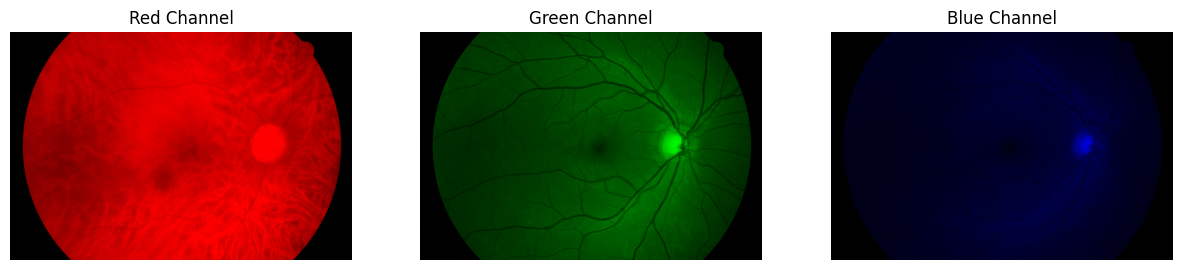

Filtering with Frangi filter..
423100 out of 8185344 pixels are in high contrast, which means about 5.168994730093201% the eye is blood vessels


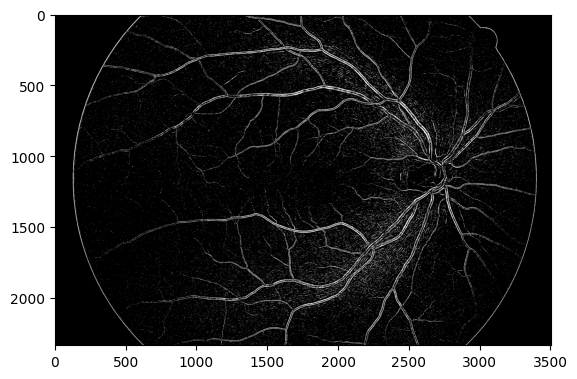

Filtering finished.


/tmp/ipykernel_12915/400329806.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  corrected_mask = morphology.remove_small_objects(mask.astype(bool), min_size=50)


Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.9183168111199724
Preprocessing the image...
Displaying color components...


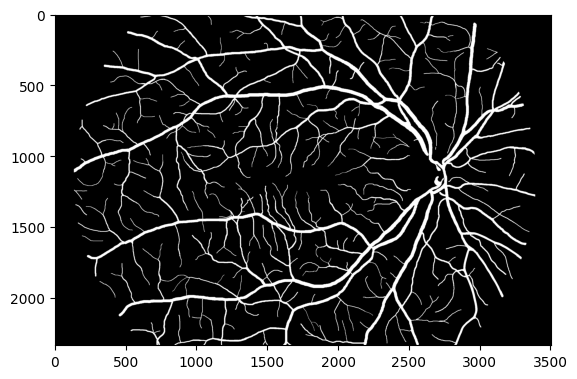

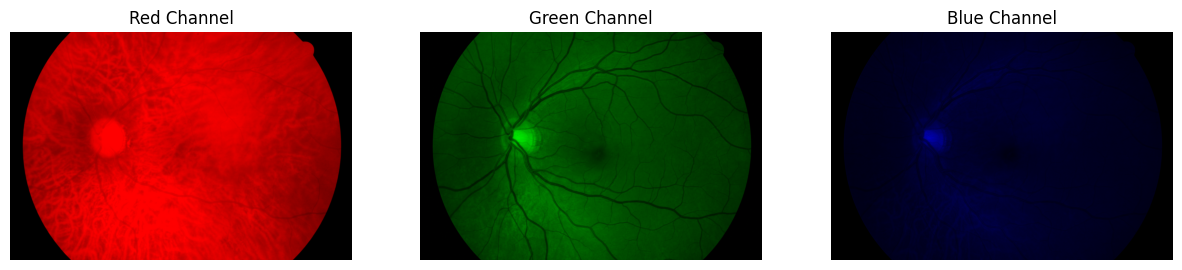

Filtering with Frangi filter..
298225 out of 8185344 pixels are in high contrast, which means about 3.643402158785263% the eye is blood vessels


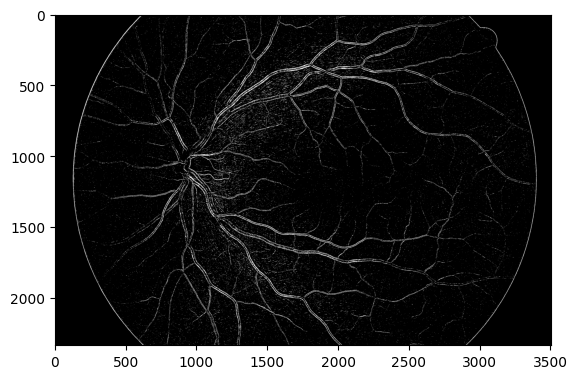

Filtering finished.
Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.91544387138769
Preprocessing the image...
Displaying color components...


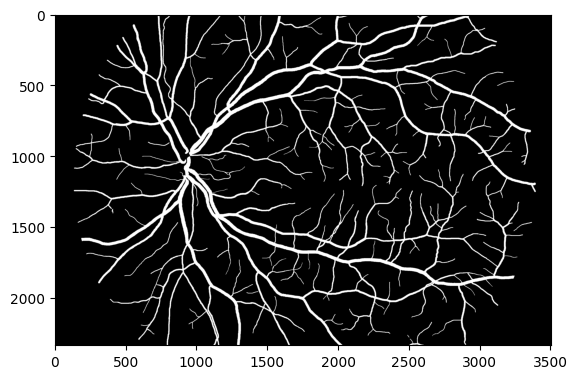

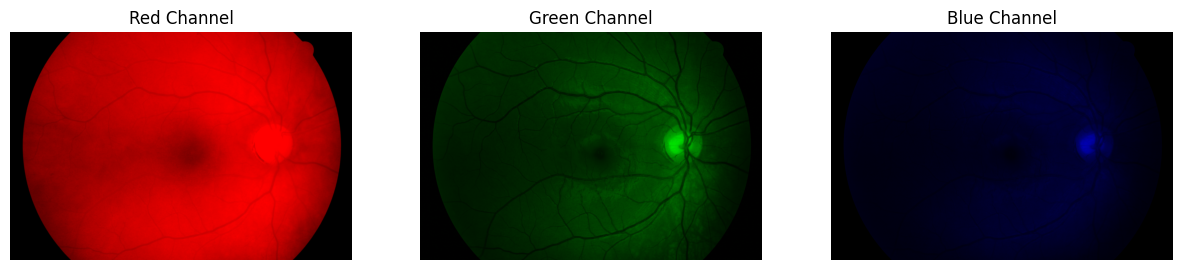

Filtering with Frangi filter..
331446 out of 8185344 pixels are in high contrast, which means about 4.049261704822668% the eye is blood vessels


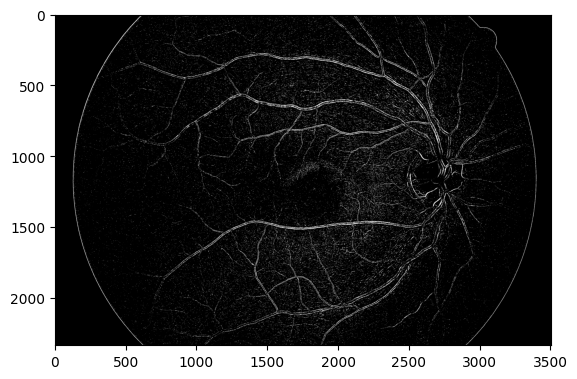

Filtering finished.
Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.9043841040767499
Preprocessing the image...
Displaying color components...


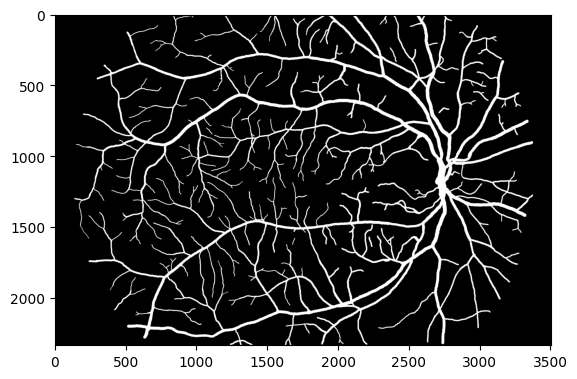

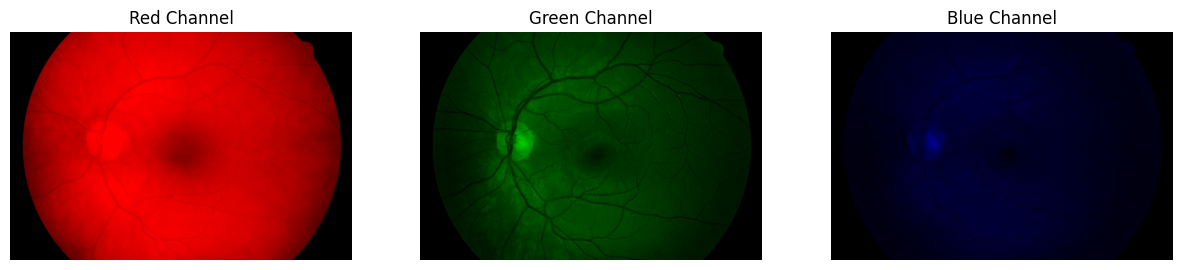

Filtering with Frangi filter..
636267 out of 8185344 pixels are in high contrast, which means about 7.773246915462563% the eye is blood vessels


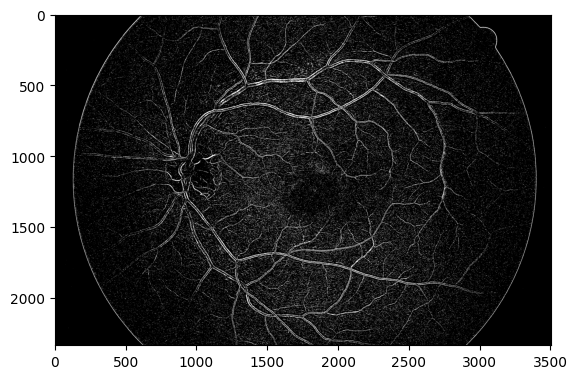

Filtering finished.
Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.925294159903359
Preprocessing the image...
Displaying color components...


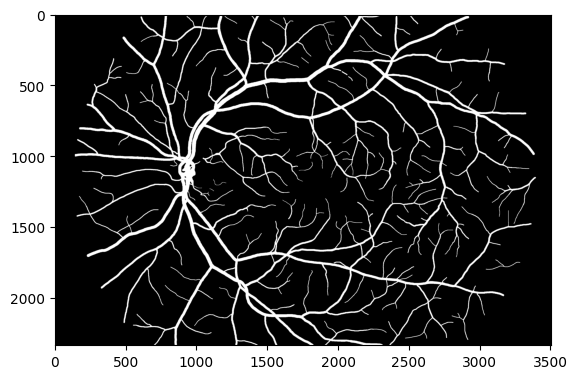

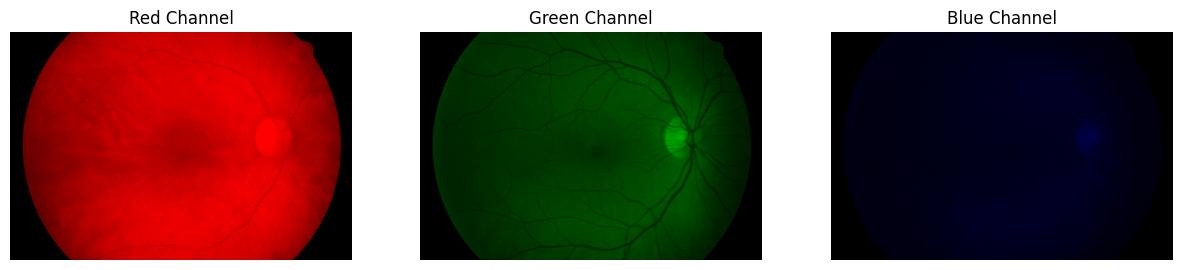

Filtering with Frangi filter..
227235 out of 8185344 pixels are in high contrast, which means about 2.776120343873147% the eye is blood vessels


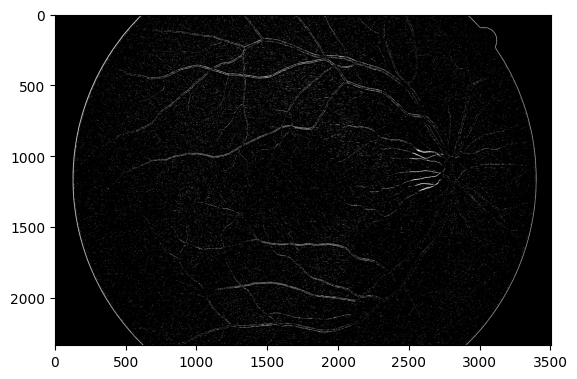

Filtering finished.
Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.9107072347845124


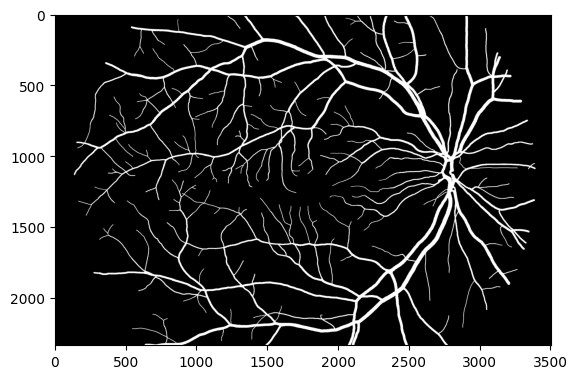

In [39]:
def custom_algorithm(img, gt):
    preprocess_image(img)
    display_color_components(r,g,b)
    mask = filter(g)
    final_mask = postprocess_segmentation(mask)
    compare_with_ground_truth(final_mask, gt)

for item in data:
    img = item['image']
    gt = item['ground_truth']
    
    r, g, b = extract_channels(img)
    custom_algorithm(img, gt)

## Uczenie maszynowe

Testujemy tylko na wycinku obrazów ze względu na 

Opening file learning_img.jpg
Opening file learning_img_goldstandard.bmp
Getting samples...
Classifying with Random Forest classifier...
======== RESULTS FOR {} =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.97      0.52      0.68    219787
         1.0       0.18      0.85      0.29     26229

    accuracy                           0.56    246016
   macro avg       0.57      0.69      0.49    246016
weighted avg       0.88      0.56      0.64    246016



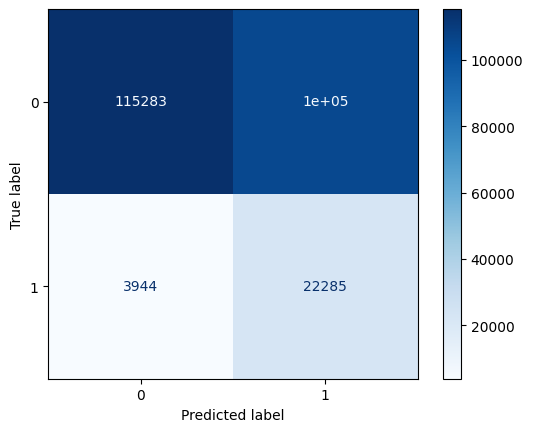

Accuracy: 0.5591831425598335
Sensitivity: 0.8496320866216783
Specficity: 0.5245214685126964


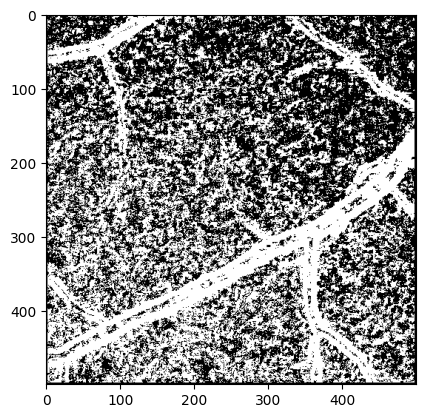

======== RESULTS FOR {} =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.78    204062
         1.0       0.35      0.87      0.49     41954

    accuracy                           0.70    246016
   macro avg       0.65      0.76      0.64    246016
weighted avg       0.86      0.70      0.73    246016



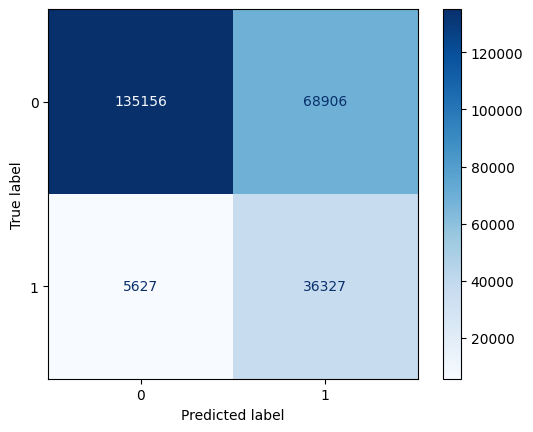

Accuracy: 0.6970400299167534
Sensitivity: 0.8658769128092673
Specficity: 0.6623281159647558


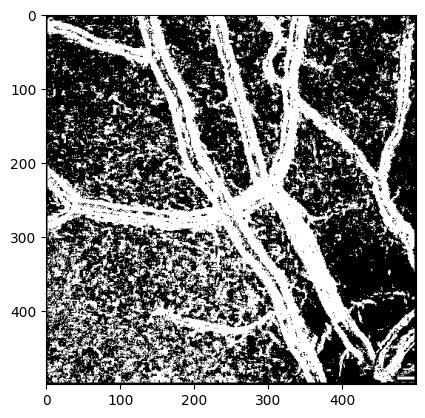

======== RESULTS FOR {} =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.97      0.45      0.62    217795
         1.0       0.17      0.88      0.29     28221

    accuracy                           0.50    246016
   macro avg       0.57      0.67      0.45    246016
weighted avg       0.88      0.50      0.58    246016



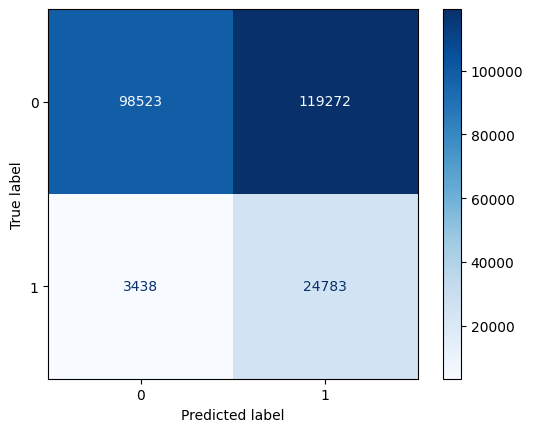

Accuracy: 0.5012113033298647
Sensitivity: 0.8781758265121717
Specficity: 0.45236575678964164


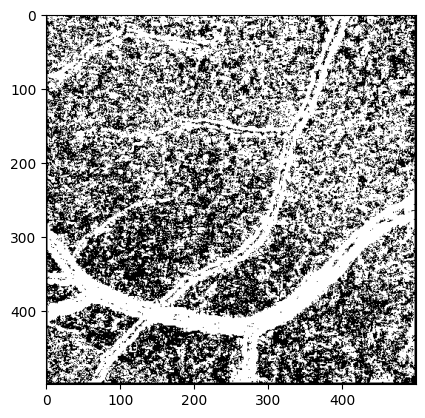

======== RESULTS FOR {} =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81    205799
         1.0       0.34      0.74      0.46     40217

    accuracy                           0.72    246016
   macro avg       0.63      0.73      0.63    246016
weighted avg       0.84      0.72      0.75    246016



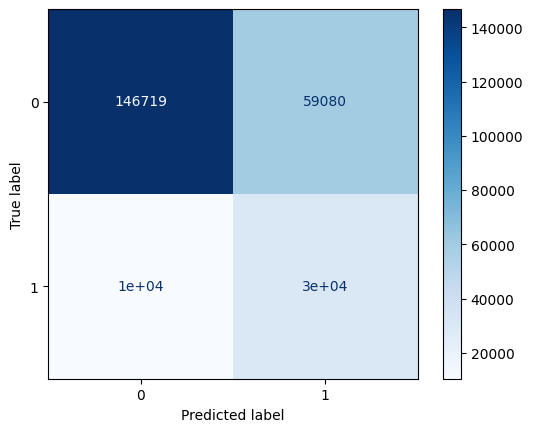

Accuracy: 0.7173761056191468
Sensitivity: 0.740159633985628
Specficity: 0.7129237751398209


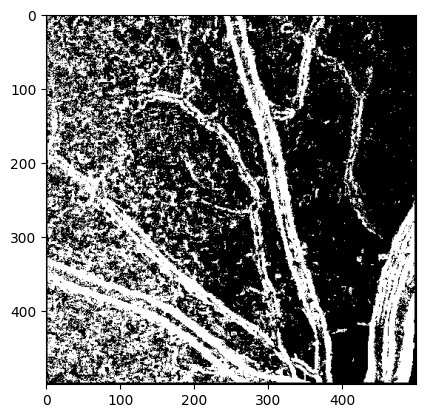

======== RESULTS FOR {} =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.95      0.51      0.67    223632
         1.0       0.13      0.73      0.22     22384

    accuracy                           0.53    246016
   macro avg       0.54      0.62      0.44    246016
weighted avg       0.88      0.53      0.63    246016



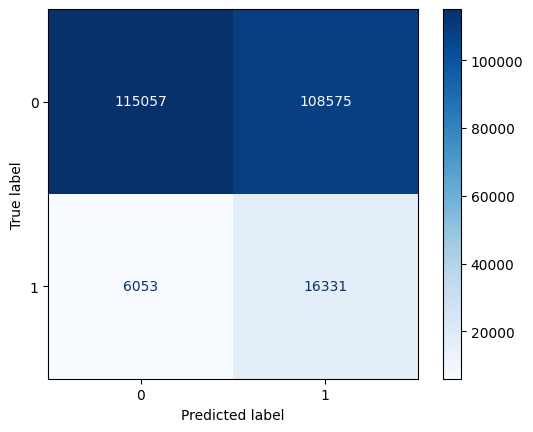

Accuracy: 0.534062825182102
Sensitivity: 0.7295836311651179
Specficity: 0.5144925592044073


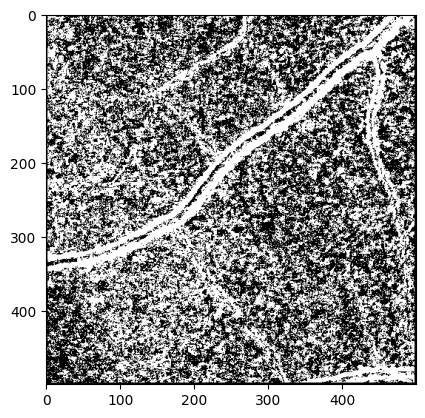

In [40]:
def machine_learning(img, gt):
    X,y = get_samples(img, gt)
    # print(X,y)
    model = classify(X,y)
    return model

learning_img_path = "learning_img.jpg"
learning_gt_path = "learning_img_goldstandard.bmp"

learning_img = open_image_file(learning_img_path)
learning_gt = open_image_file(learning_gt_path)

model = machine_learning(learning_img, learning_gt)

for item in data:
    img = item['image']
    gt = item['ground_truth']

    h_start, w_start = 500, 500
    h_size, w_size = 500, 500
    
    img_roi = img[h_start:h_start+h_size, w_start:w_start+w_size]
    gt_roi = gt[h_start:h_start+h_size, w_start:w_start+w_size]

    X_test, y_test = sliding_window(img_roi, gt_roi)
    X_test = np.array(X_test).astype(float)

    prediction = model.predict(X_test)

    print("======== RESULTS FOR {} =========")
    calculate_metrics(y_test, prediction, model=model)

    offset = window_shape[0] // 2
    pred_image = np.zeros((h_size, w_size))
    pred_image[offset:h_size-offset, offset:w_size-offset] = prediction.reshape(h_size - 2*offset, w_size - 2*offset)

    plt.imshow(pred_image, cmap='gray')
    plt.show()


## Uczenie głębokie

In [ ]:
learning_patches = get_patches(learning_img)
gt_patches = get_patches(learning_gt)

model_path = 'trained_DL.keras'

if os.path.exists(model_path):
    print("Importing the DL model...")
    model = tf.keras.models.load_model(model_path)
else:
    print("Model doesn't exist. Training...")
    learning_patches = get_patches(learning_img)
    gt_patches = get_patches(learning_gt)
    model = deep_learning(learning_patches, gt_patches)
    
for item in data:
    img = item['image']
    gt = item['ground_truth']

    patches = get_patches(img)

    full_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.unit8)

    for (x,y), patch in patches:
        img_array = np.array(patch) / 255.0  # normalization
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)
        pred_mask = np.squeeze(prediction, axis=0)
        pred_mask = np.argmax(pred_mask, axis=-1).astype(np.uint8) * 255

        full_mask[y:y+128,x:x+128]
    
    final_result = Image.fromarray(full_mask)
    final_result.save('predicted_full_mask.jpg')
    print("Prediction saved.")

    calculate_metrics(gt.flatten(), full_mask.flatten())

    compare_with_ground_truth(final_result, gt)

       

Model doesn't exist. Training...
Training DL model...


# Wyniki

tabelka z wynikami do porównania

<table>
  <tr>
    <th colspan="2"></th>
    <th>Filter</th>
    <th>ML</th>
    <th>DL</th>
  </tr>
  <tr>
    <td rowspan="3">1</td>
    <td>Accuracy</td>
    <td></td>
    <td>0.5718245967741935</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td></td>
    <td>0.8357924434785924</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td></td>
    <td>0.5403231310314077</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">2</td>
    <td>Accuracy</td>
    <td></td>
    <td>0.6965319328824141</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td></td>
    <td>0.8668541736187253</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td></td>
    <td>0.6615146377081476</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">3</td>
    <td>Accuracy</td>
    <td></td>
    <td>0.5577157583246618</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td></td>
    <td>0.8777506112469438</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td></td>
    <td> 0.5162469294520077</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">4</td>
    <td>Accuracy</td>
    <td></td>
    <td>0.7214124284599376</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td></td>
    <td>0.7384190765099337</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td></td>
    <td>0.718089009178859</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">5</td>
    <td>Accuracy</td>
    <td></td>
    <td>0.5776738098335068</td>
    <td></td>
  </tr>
   <tr>
    <td>Sensitivity</td>
    <td></td>
    <td>0.7012598284488921</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td></td>
    <td> 0.5653037132431852</td>
    <td></td>
  </tr>
</table>